In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from IPython.display import display, HTML
from sklearn.metrics import root_mean_squared_error
from matplotlib.patches import Patch

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})

PERSIST_COLOR = '#78909C'

def show_plotly(fig):
    display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))

# ── load result CSVs ──────────────────────────────────────────────────────────
temporal = pd.read_csv('../datasets/temporal_results.csv', parse_dates=['Date'])
spatial  = pd.read_csv('../datasets/spatial_results.csv',  parse_dates=['Date'])
gnn      = pd.read_csv('../datasets/gnn_results.csv',       parse_dates=['Date'])

# 3-model ensemble (non-negative OLS)
from src.evaluation.ensemble import build_ensemble
ens_raw, ens_weights = build_ensemble(
    '../datasets/temporal_results.csv',
    '../datasets/spatial_results.csv',
    gnn_csv='../datasets/gnn_results.csv',
)
# normalise to consistent column names + datetime Date
ens = ens_raw.rename(columns={'y_test': 'Y Test', 'y_pred_ensemble': 'Y Pred'})
ens['Date'] = pd.to_datetime(ens['Date'])

print(f"Ensemble weights — temporal: {ens_weights[0]:.3f}  "
      f"spatial: {ens_weights[1]:.3f}  GNN: {ens_weights[2]:.3f}")
print(f"temporal rows: {len(temporal):,}  |  ensemble rows: {len(ens):,}")

Ensemble weights — temporal: 0.522  spatial: 0.325  GNN: 0.160
temporal rows: 179,092  |  ensemble rows: 179,007


## 1 · AQI-stratified RMSE

Do models add value on the **days that matter most**?

| Tier | PM2.5 range | EPA AQI colour |
|---|---|---|
| Good | < 12 µg/m³ | Green |
| Moderate | 12–35 µg/m³ | Yellow–Orange |
| Unhealthy | ≥ 35 µg/m³ | Red–Hazardous |

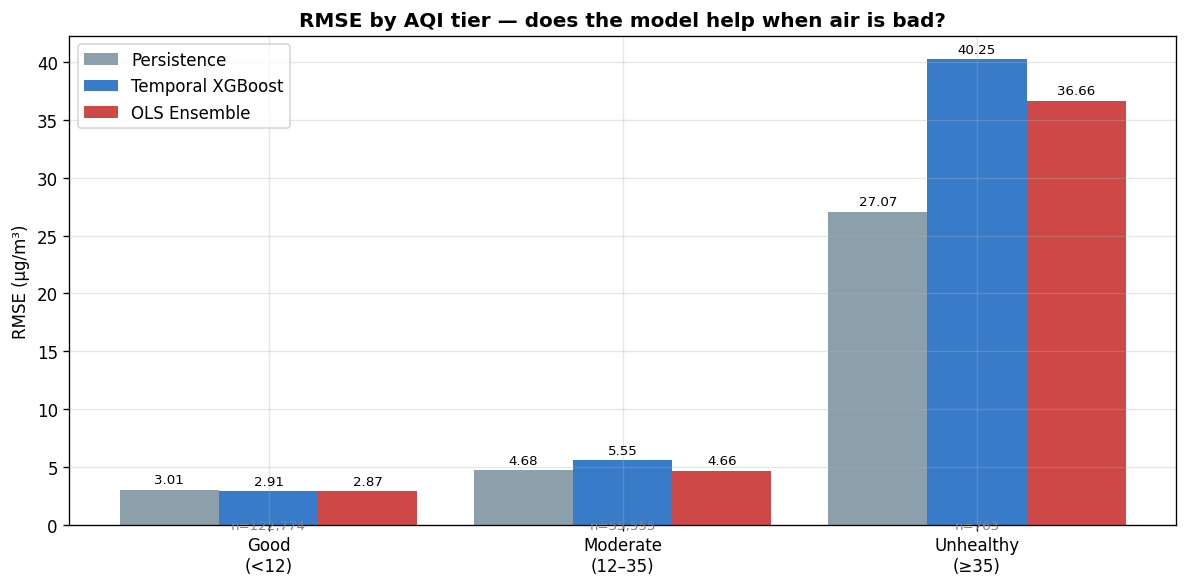

Persistence           Good: 3.01  Moderate: 4.68  Unhealthy: 27.07
Temporal XGBoost      Good: 2.91  Moderate: 5.55  Unhealthy: 40.25
OLS Ensemble          Good: 2.87  Moderate: 4.66  Unhealthy: 36.66


In [2]:
def aqi_bin(v):
    if v < 12:  return 'Good\n(<12)'
    if v < 35:  return 'Moderate\n(12–35)'
    return 'Unhealthy\n(≥35)'

BIN_ORDER = ['Good\n(<12)', 'Moderate\n(12–35)', 'Unhealthy\n(≥35)']

def rmse_by_bin(df, pred_col):
    df = df.copy()
    df['bin'] = df['Y Test'].apply(aqi_bin)
    return {
        b: root_mean_squared_error(sub['Y Test'], sub[pred_col])
        for b in BIN_ORDER
        if len(sub := df[df['bin'] == b]) > 0
    }

def persist_rmse_by_bin(df):
    df = df.sort_values(['Sensor Index', 'Date']).copy()
    df['y_persist'] = df.groupby('Sensor Index')['Y Test'].shift(1)
    df = df.dropna(subset=['y_persist'])
    df['bin'] = df['Y Test'].apply(aqi_bin)
    return {
        b: root_mean_squared_error(sub['Y Test'], sub['y_persist'])
        for b in BIN_ORDER
        if len(sub := df[df['bin'] == b]) > 0
    }

results = {
    'Persistence':      persist_rmse_by_bin(temporal),
    'Temporal XGBoost': rmse_by_bin(temporal, 'Y Pred'),
    'OLS Ensemble':     rmse_by_bin(ens, 'Y Pred'),
}
counts = temporal.assign(bin=temporal['Y Test'].apply(aqi_bin)).groupby('bin').size().to_dict()

fig, ax = plt.subplots(figsize=(10, 5))
x      = np.arange(len(BIN_ORDER))
width  = 0.28
colors = [PERSIST_COLOR, '#1565C0', '#C62828']

for i, (model, vals) in enumerate(results.items()):
    heights = [vals.get(b, 0) for b in BIN_ORDER]
    bars = ax.bar(x + (i - 1) * width, heights, width,
                  label=model, color=colors[i], alpha=0.85)
    ax.bar_label(bars, fmt='%.2f', fontsize=8, padding=2)

for j, b in enumerate(BIN_ORDER):
    n = counts.get(b, 0)
    ax.text(x[j], -0.4, f'n={n:,}', ha='center', fontsize=8, color='grey')

ax.set_xticks(x)
ax.set_xticklabels(BIN_ORDER)
ax.set_ylabel('RMSE (µg/m³)')
ax.set_title('RMSE by AQI tier — does the model help when air is bad?', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../assets/aqi_stratified_rmse.png', dpi=150)
plt.show()

for model, vals in results.items():
    line = '  '.join(f"{b.split(chr(10))[0]}: {v:.2f}" for b, v in vals.items())
    print(f"{model:20s}  {line}")

## 2 · Seasonal RMSE

LA has a strong **winter inversion** cycle (PM2.5 peaks Dec–Feb) driven by temperature inversions
trapping pollution in the basin. Summer is drier and windier, with lower and more stable PM2.5.

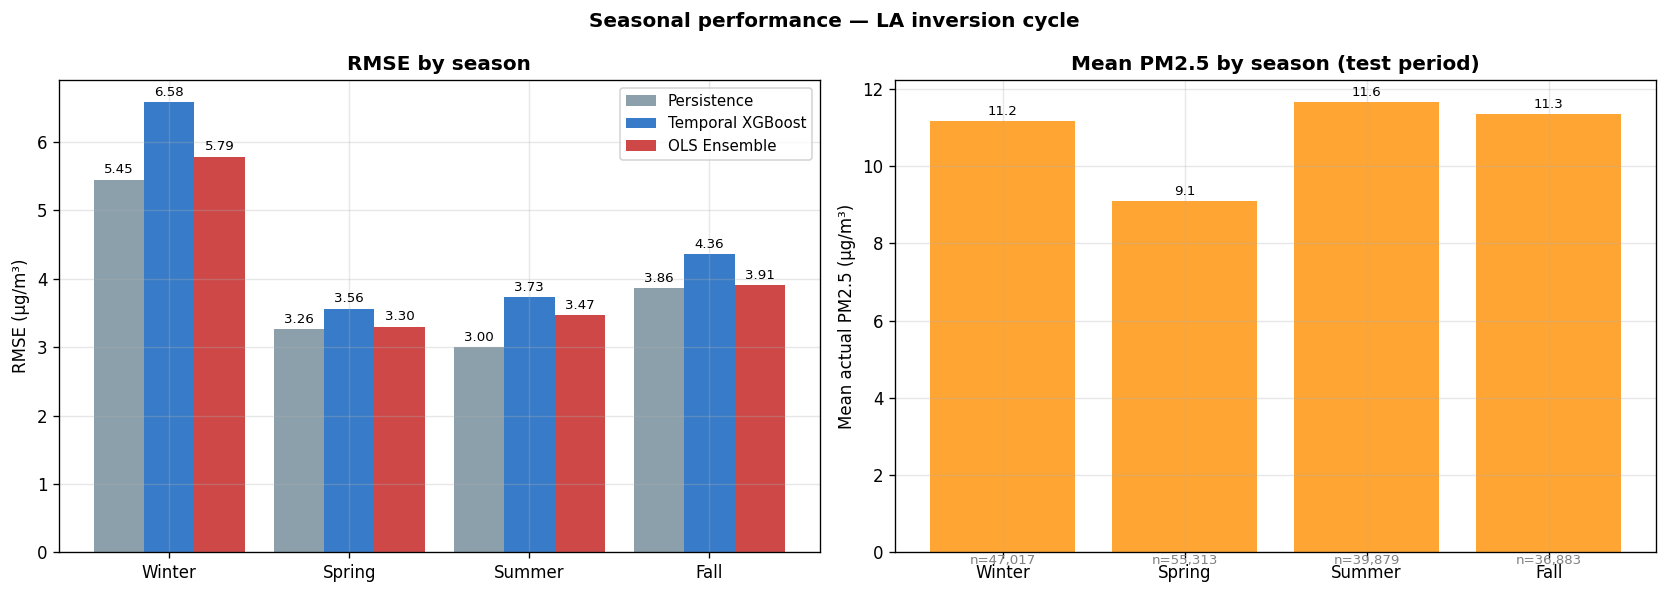

Season    Persist   Temporal   Ensemble   MeanPM2.5
Winter       5.45       6.58       5.79       11.16
Spring       3.26       3.56       3.30        9.09
Summer       3.00       3.73       3.47       11.64
Fall         3.86       4.36       3.91       11.33


In [3]:
SEASON_MAP = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Fall',   10: 'Fall',   11: 'Fall'}
SEASON_ORDER = ['Winter', 'Spring', 'Summer', 'Fall']

def seasonal_rmse(df, pred_col):
    df = df.copy()
    df['Season'] = df['Date'].dt.month.map(SEASON_MAP)
    return {
        s: {'rmse':     root_mean_squared_error(sub['Y Test'], sub[pred_col]),
            'n':        len(sub),
            'mean_pm':  sub['Y Test'].mean()}
        for s in SEASON_ORDER
        if len(sub := df[df['Season'] == s]) > 0
    }

def persist_seasonal(df):
    df = df.sort_values(['Sensor Index', 'Date']).copy()
    df['y_p'] = df.groupby('Sensor Index')['Y Test'].shift(1)
    df = df.dropna(subset=['y_p'])
    df['Season'] = df['Date'].dt.month.map(SEASON_MAP)
    return {
        s: root_mean_squared_error(sub['Y Test'], sub['y_p'])
        for s in SEASON_ORDER
        if len(sub := df[df['Season'] == s]) > 0
    }

t_seas = seasonal_rmse(temporal, 'Y Pred')
e_seas = seasonal_rmse(ens, 'Y Pred')
p_seas = persist_seasonal(temporal)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x  = np.arange(len(SEASON_ORDER))
w  = 0.28
triplets = [
    ('Persistence',      [p_seas.get(s, 0) for s in SEASON_ORDER],              PERSIST_COLOR),
    ('Temporal XGBoost', [t_seas[s]['rmse'] for s in SEASON_ORDER],              '#1565C0'),
    ('OLS Ensemble',     [e_seas[s]['rmse'] for s in SEASON_ORDER],              '#C62828'),
]
for i, (label, vals, color) in enumerate(triplets):
    bars = ax.bar(x + (i - 1) * w, vals, w, label=label, color=color, alpha=0.85)
    ax.bar_label(bars, fmt='%.2f', fontsize=8, padding=2)
ax.set_xticks(x)
ax.set_xticklabels(SEASON_ORDER)
ax.set_ylabel('RMSE (µg/m³)')
ax.set_title('RMSE by season', fontweight='bold')
ax.legend(fontsize=9)

ax2 = axes[1]
mean_pm = [t_seas[s]['mean_pm'] for s in SEASON_ORDER]
ns      = [t_seas[s]['n']       for s in SEASON_ORDER]
bars2   = ax2.bar(SEASON_ORDER, mean_pm, color='#FF8F00', alpha=0.8)
ax2.bar_label(bars2, fmt='%.1f', fontsize=8, padding=2)
for j, (s, n) in enumerate(zip(SEASON_ORDER, ns)):
    ax2.text(j, -0.3, f'n={n:,}', ha='center', fontsize=8, color='grey')
ax2.set_ylabel('Mean actual PM2.5 (µg/m³)')
ax2.set_title('Mean PM2.5 by season (test period)', fontweight='bold')

fig.suptitle('Seasonal performance — LA inversion cycle', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/seasonal_rmse.png', dpi=150)
plt.show()

print(f"{'Season':8s} {'Persist':>8s} {'Temporal':>10s} {'Ensemble':>10s} {'MeanPM2.5':>11s}")
for s in SEASON_ORDER:
    print(f"{s:8s} {p_seas.get(s,0):8.2f} {t_seas[s]['rmse']:10.2f} "
          f"{e_seas[s]['rmse']:10.2f} {t_seas[s]['mean_pm']:11.2f}")

## 3 · Per-sensor RMSE map

Where do prediction errors cluster? High-RMSE sensors tend to be near freeways, industrial
zones, or at the edge of wildfire corridors (Santa Ana canyon mouths).

In [4]:
# temporal_results.csv already has Latitude / Longitude
per_sensor = (
    temporal.groupby(['Sensor Index', 'Latitude', 'Longitude'])
    .apply(
        lambda g: pd.Series({
            'RMSE':     root_mean_squared_error(g['Y Test'], g['Y Pred']),
            'N':        len(g),
            'Mean PM25': g['Y Test'].mean(),
        }),
        include_groups=False,
    )
    .reset_index()
)

# per-sensor persistence RMSE for skill score
persist_per = (
    temporal.sort_values(['Sensor Index', 'Date'])
    .assign(y_p=lambda df: df.groupby('Sensor Index')['Y Test'].shift(1))
    .dropna(subset=['y_p'])
    .groupby('Sensor Index')
    .apply(lambda g: root_mean_squared_error(g['Y Test'], g['y_p']),
           include_groups=False)
    .rename('Persist RMSE')
    .reset_index()
)
per_sensor = per_sensor.merge(persist_per, on='Sensor Index')
per_sensor['Skill'] = (1 - per_sensor['RMSE'] / per_sensor['Persist RMSE']).round(3)

n_beat = (per_sensor['Skill'] > 0).sum()
print(f"Sensors beating persistence: {n_beat} / {len(per_sensor)} ({100*n_beat/len(per_sensor):.0f}%)")
print("Top-5 highest-error sensors:")
print(per_sensor.nlargest(5, 'RMSE')
      [['Sensor Index', 'Latitude', 'Longitude', 'RMSE', 'Mean PM25']].to_string(index=False))

fig = px.scatter_map(
    per_sensor,
    lat='Latitude', lon='Longitude',
    color='RMSE',
    size='N',
    size_max=14,
    color_continuous_scale='RdYlGn_r',
    hover_data={'Sensor Index': True, 'RMSE': ':.2f',
                'Mean PM25': ':.1f', 'N': True, 'Skill': True,
                'Persist RMSE': ':.2f'},
    zoom=9,
    center={'lat': 34.05, 'lon': -118.25},
    map_style='carto-positron',
    title='Temporal XGBoost — per-sensor RMSE (red = high error, green = low error)',
    height=600,
)
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0),
                  coloraxis_colorbar_title='RMSE (µg/m³)')
show_plotly(fig)

Sensors beating persistence: 35 / 218 (16%)
Top-5 highest-error sensors:
 Sensor Index  Latitude   Longitude      RMSE  Mean PM25
      2000443 34.181680 -118.409960 19.888469  14.683170
      7526877 34.214630 -118.433310 12.975873  11.849931
      6895828 34.293270 -118.579950 12.738688   9.752500
      2001059 34.034110 -118.391600 10.983136  12.665716
      6530275 34.135396 -118.101396  9.488734  12.097647


In [5]:
# Skill score map — green = model beats persistence, red = model loses
fig2 = px.scatter_map(
    per_sensor,
    lat='Latitude', lon='Longitude',
    color='Skill',
    size='N',
    size_max=14,
    color_continuous_scale='RdYlGn',
    range_color=[-1.0, 0.5],
    hover_data={'Sensor Index': True, 'RMSE': ':.2f',
                'Persist RMSE': ':.2f', 'Skill': True},
    zoom=9,
    center={'lat': 34.05, 'lon': -118.25},
    map_style='carto-positron',
    title='Skill score vs persistence (green = model wins, red = model loses)',
    height=600,
)
fig2.update_layout(margin=dict(l=0, r=0, t=40, b=0),
                   coloraxis_colorbar_title='Skill score')
show_plotly(fig2)

## 4 · XGBoost feature importance

Mean gain importance aggregated across all per-sensor models.
Which features does the temporal XGBoost actually rely on?

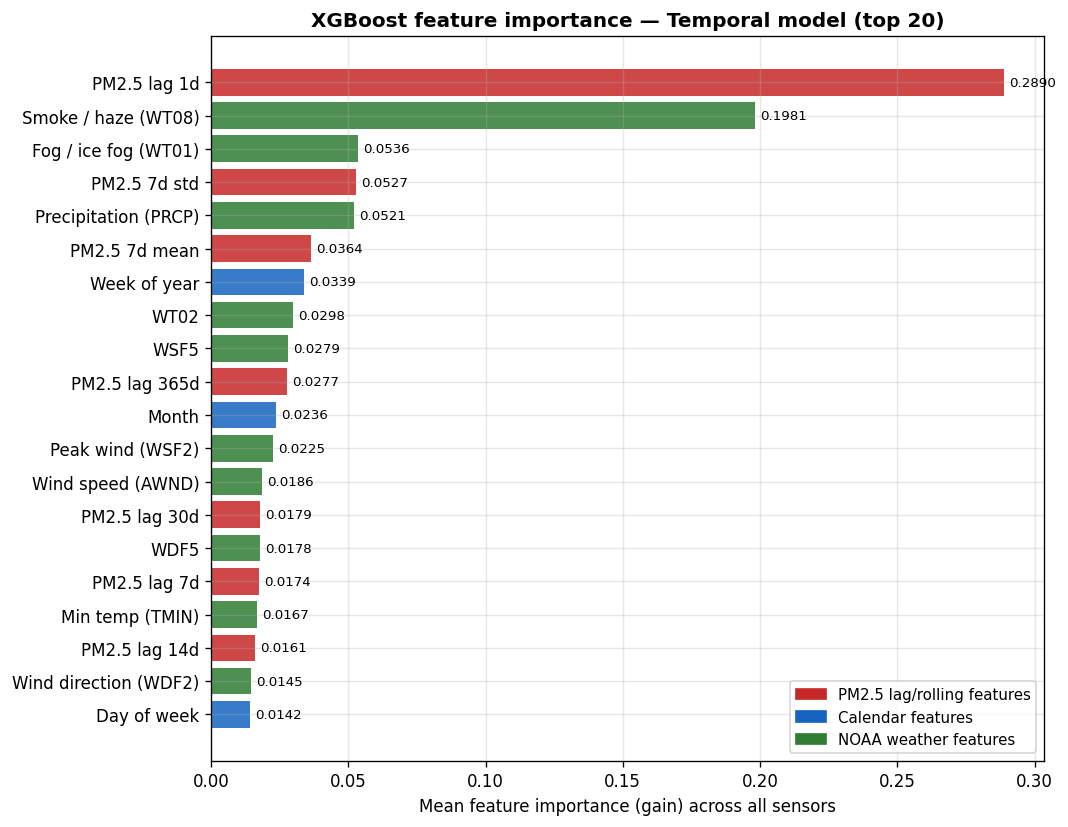

Top 5 features:
  PM2.5 lag 1d                         0.2890  (29.5%)
  Smoke / haze (WT08)                  0.1981  (20.2%)
  Fog / ice fog (WT01)                 0.0536  (5.5%)
  PM2.5 7d std                         0.0527  (5.4%)
  Precipitation (PRCP)                 0.0521  (5.3%)


In [6]:
imp = pd.read_csv('../datasets/temporal_feature_importance.csv', index_col=0)
imp.columns = ['importance']
imp = imp.sort_values('importance', ascending=True).tail(20)

LABEL = {
    'pm25_lag1':      'PM2.5 lag 1d',
    'pm25_lag7':      'PM2.5 lag 7d',
    'pm25_lag14':     'PM2.5 lag 14d',
    'pm25_lag30':     'PM2.5 lag 30d',
    'pm25_lag365':    'PM2.5 lag 365d',
    'pm25_roll7':     'PM2.5 7d mean',
    'pm25_roll7_std': 'PM2.5 7d std',
    'month':          'Month',
    'week_of_year':   'Week of year',
    'day_of_week':    'Day of week',
    'AWND':           'Wind speed (AWND)',
    'TMAX':           'Max temp (TMAX)',
    'TMIN':           'Min temp (TMIN)',
    'PRCP':           'Precipitation (PRCP)',
    'WSF2':           'Peak wind (WSF2)',
    'WDF2':           'Wind direction (WDF2)',
    'SNOW':           'Snowfall (SNOW)',
    'WT01':           'Fog / ice fog (WT01)',
    'WT08':           'Smoke / haze (WT08)',
}
imp.index = [LABEL.get(f, f) for f in imp.index]

def feat_color(label):
    if 'PM2.5' in label:  return '#C62828'
    if label in ('Month', 'Week of year', 'Day of week'):  return '#1565C0'
    return '#2E7D32'

colors = [feat_color(l) for l in imp.index]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(imp.index, imp['importance'], color=colors, alpha=0.85)
ax.bar_label(bars, fmt='%.4f', fontsize=8, padding=3)
ax.set_xlabel('Mean feature importance (gain) across all sensors')
ax.set_title('XGBoost feature importance — Temporal model (top 20)', fontweight='bold')
ax.legend(handles=[
    Patch(color='#C62828', label='PM2.5 lag/rolling features'),
    Patch(color='#1565C0', label='Calendar features'),
    Patch(color='#2E7D32', label='NOAA weather features'),
], loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../assets/feature_importance.png', dpi=150)
plt.show()

total = imp['importance'].sum()
print("Top 5 features:")
for feat, row in imp.sort_values('importance', ascending=False).head(5).iterrows():
    print(f"  {feat:35s}  {row['importance']:.4f}  ({100*row['importance']/total:.1f}%)")